## NER Model Training

This notebook trains three models and save them into `fitted_models/`:
1. CRF (Conditional Random Fields with handcrafted features)
2. Structured Perceptron
3. BILDTM-CRF (Deep Learning)
4. BERT fine-tuned for NER (bert-base-cased + token classifier)

Run `reproduce_results.ipynb` to load and evaluate them.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'utils'))

import random, pickle, json
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import sklearn_crfsuite

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchcrf import CRF

import logging
logging.getLogger("transformers").setLevel(logging.ERROR)
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)

from utils import (
    load_ner_csv, encode_crf, build_vocab, build_tag_map,
    sp_token_features, sp_viterbi, sp_update,
    evaluate_model,
    train_structured_perceptron
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR   = Path('data')
MODEL_DIR  = Path('fitted_models')
MODEL_DIR.mkdir(exist_ok=True)
print('Setup OK')

Setup OK


## 1. Load data

In [2]:
train_sents, train_labels = load_ner_csv(DATA_DIR / "train_data_ner.csv")
test_sents, test_labels   = load_ner_csv(DATA_DIR / "test_data_ner.csv")

print(f"Train sentences: {len(train_sents)}")
print(f"Test sentences: {len(test_sents)}")
print(f"Sample train sentence: {train_sents[0]}")
print(f"Sample train labels: {train_labels[0]}")
print(f"Sample test sentence: {test_sents[0]}")
print(f"Sample test labels: {test_labels[0]}")

all_labels = sorted({t for labels in train_labels + test_labels for t in labels})
non_O_labels = [t for t in all_labels if t != 'O']
print(f"All labels: {all_labels}")

Train sentences: 38366
Test sentences: 38367
Sample train sentence: ['Thousands', 'of', 'demonstrators', 'have', 'marched', 'through', 'London', 'to', 'protest', 'the', 'war', 'in', 'Iraq', 'and', 'demand', 'the', 'withdrawal', 'of', 'British', 'troops', 'from', 'that', 'country', '.']
Sample train labels: ['O', 'O', 'O', 'O', 'O', 'O', 'B-geo', 'O', 'O', 'O', 'O', 'O', 'B-geo', 'O', 'O', 'O', 'O', 'O', 'B-gpe', 'O', 'O', 'O', 'O', 'O']
Sample test sentence: ['Iranian', 'officials', 'say', 'they', 'expect', 'to', 'get', 'access', 'to', 'sealed', 'sensitive', 'parts', 'of', 'the', 'plant', 'Wednesday', ',', 'after', 'an', 'IAEA', 'surveillance', 'system', 'begins', 'functioning', '.']
Sample test labels: ['B-gpe', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-tim', 'O', 'O', 'O', 'B-org', 'O', 'O', 'O', 'O', 'O']
All labels: ['B-art', 'B-eve', 'B-geo', 'B-gpe', 'B-nat', 'B-org', 'B-per', 'B-tim', 'I-art', 'I-eve', 'I-geo', 'I-gpe', 'I-nat', 'I-org', 'I-per', '

## 2. EDA

In [3]:
def eda(sents, labels, split_name):
    flat_labels = [t for seq in labels for t in seq]
    flat_words = [w for s in sents for w in s]
    sent_lens = [len(s) for s in sents]
    counts = Counter(flat_labels)

    print(f"{split_name} data:")
    print(f"Sentences: {len(sents)}")
    print(f"Tokens: {len(flat_words)}")
    print(f"Unique tok: {len(set(flat_words))}")
    print(
        f"Sent len: min={min(sent_lens)}, max={max(sent_lens)}, mean={np.mean(sent_lens):.1f}"
    )
    print(f"Label dist:")
    for lbl, cnt in sorted(counts.items(), key=lambda x: -x[1]):
        print(f"{lbl:15s}: {cnt:6d}  ({100*cnt/len(flat_labels):.1f}%)")


eda(train_sents, train_labels, "TRAIN")
print()
eda(test_sents, test_labels, "TEST")

TRAIN data:
Sentences: 38366
Tokens: 839141
Unique tok: 31978
Sent len: min=1, max=104, mean=21.9
Label dist:
O              : 710383  (84.7%)
B-geo          :  30113  (3.6%)
B-tim          :  16317  (1.9%)
B-org          :  16127  (1.9%)
I-per          :  13845  (1.6%)
B-per          :  13568  (1.6%)
I-org          :  13526  (1.6%)
B-gpe          :  12739  (1.5%)
I-geo          :   5898  (0.7%)
I-tim          :   5258  (0.6%)
B-art          :    314  (0.0%)
B-eve          :    244  (0.0%)
I-art          :    242  (0.0%)
I-eve          :    205  (0.0%)
I-gpe          :    161  (0.0%)
B-nat          :    157  (0.0%)
I-nat          :     44  (0.0%)

TEST data:
Sentences: 38367
Tokens: 837330
Unique tok: 43954
Sent len: min=1, max=104, mean=21.8
Label dist:
O              : 709097  (84.7%)
B-geo          :  30114  (3.6%)
B-tim          :  16131  (1.9%)
B-org          :  16019  (1.9%)
I-per          :  13830  (1.7%)
B-per          :  13691  (1.6%)
I-org          :  13281  (1.6%)
B-gpe     

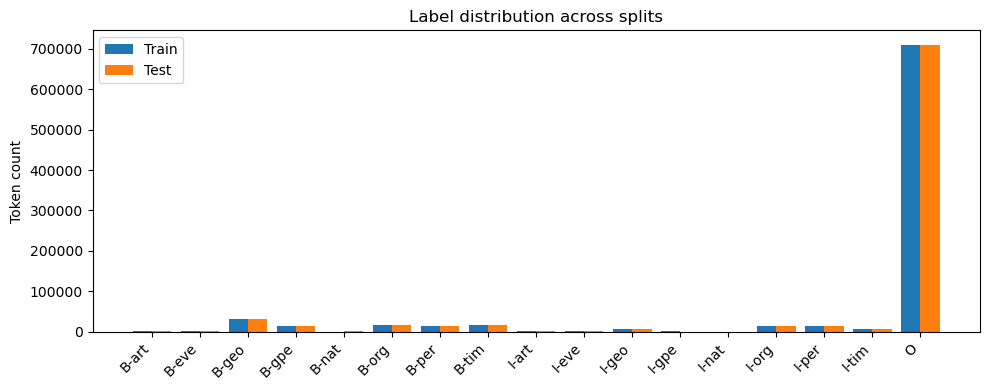

In [4]:
train_counts = Counter(t for seq in train_labels for t in seq)
test_counts  = Counter(t for seq in test_labels  for t in seq)
labs = sorted(train_counts.keys())

x = np.arange(len(labs))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, [train_counts[l] for l in labs], 0.4, label='Train')
ax.bar(x + 0.2, [test_counts.get(l, 0) for l in labs], 0.4, label='Test')
ax.set_xticks(x); ax.set_xticklabels(labs, rotation=45, ha='right')
ax.set_ylabel('Token count')
ax.set_title('Label distribution across splits')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'label_distribution.png', dpi=120)
plt.show()

## 3. Model 01: CRF

In [6]:
X_train_crf, y_train_crf = encode_crf(train_sents, train_labels)
X_test_crf,  y_test_crf  = encode_crf(test_sents,  test_labels)
print('CRF features ready')

CRF features ready


In [8]:
CRF_PATH = MODEL_DIR / "crf_model.pkl"

if CRF_PATH.exists():
    print(f"CRF already trained, loading from {CRF_PATH}")
    with open(CRF_PATH, "rb") as f:
        crf = pickle.load(f)
else:
    crf = sklearn_crfsuite.CRF(
        algorithm="lbfgs",
        c1=0.01,
        c2=0.01,
        max_iterations=150,
        all_possible_transitions=True,
        verbose=True,
    )
    crf.fit(X_train_crf, y_train_crf)
    with open(CRF_PATH, "wb") as f:
        pickle.dump(crf, f)
    print(f"CRF trained and saved to {CRF_PATH}")

y_pred_crf_train = crf.predict(X_train_crf)
res = evaluate_model(y_train_crf, y_pred_crf_train, exclude_O=True)
print(
    f'CRF TRAIN accuracy (non-O): {res["accuracy"]:.4f}  F1-macro: {res["f1_macro"]:.4f}'
)

CRF already trained, loading from fitted_models/crf_model.pkl
CRF TRAIN accuracy (non-O): 0.9760  F1-macro: 0.9714


In [7]:
# Quick sanity check with the test set
y_pred_crf_train = crf.predict(X_train_crf)
res = evaluate_model(y_train_crf, y_pred_crf_train, exclude_O=True)
print(f'CRF TRAIN accuracy (non-O): {res["accuracy"]:.4f}  F1-macro: {res["f1_macro"]:.4f}')

CRF TRAIN accuracy (non-O): 0.9760  F1-macro: 0.9714


## Model 02: Structured Perceptron

In [9]:
SP_PATH = MODEL_DIR / "sp_model.pkl"

if SP_PATH.exists():
    print(f"Structured Perceptron already trained, loading from {SP_PATH}")
    with open(SP_PATH, "rb") as f:
        sp_artifact = pickle.load(f)
    sp_weights = defaultdict(float, sp_artifact["weights"])
else:
    print("Training Structured Perceptron...")
    sp_weights = train_structured_perceptron(
        train_sents, train_labels, all_labels, n_epochs=10
    )
    sp_artifact = {"weights": dict(sp_weights), "label_set": all_labels}
    with open(SP_PATH, "wb") as f:
        pickle.dump(sp_artifact, f)
    print(f"Structured Perceptron saved to {SP_PATH}")

y_pred_sp_train = [
    sp_viterbi(sp_weights, s, all_labels, sp_token_features)
    for s in tqdm(train_sents, desc="Predicting train")
]
res = evaluate_model(train_labels, y_pred_sp_train, exclude_O=True)
print(
    f'SP TRAIN accuracy (non-O): {res["accuracy"]:.4f}  F1-macro: {res["f1_macro"]:.4f}'
)

Structured Perceptron already trained — loading from fitted_models/sp_model.pkl


Predicting train:   0%|          | 0/38366 [00:00<?, ?it/s]

SP TRAIN accuracy (non-O): 0.8812  F1-macro: 0.8224


## 5. Model 03: BILDTM-CRF (Deep Learning)

In [5]:
vocab = build_vocab(train_sents)
tag_map = build_tag_map(train_labels)
id2tag = {v: k for k, v in tag_map.items()}

print(f"Vocab size: {len(vocab)}")
print(f"Tag map: {tag_map}")
print(f"ID to tag: {id2tag}")

Vocab size: 31980
Tag map: {'B-art': 0, 'B-eve': 1, 'B-geo': 2, 'B-gpe': 3, 'B-nat': 4, 'B-org': 5, 'B-per': 6, 'B-tim': 7, 'I-art': 8, 'I-eve': 9, 'I-geo': 10, 'I-gpe': 11, 'I-nat': 12, 'I-org': 13, 'I-per': 14, 'I-tim': 15, 'O': 16}
ID to tag: {0: 'B-art', 1: 'B-eve', 2: 'B-geo', 3: 'B-gpe', 4: 'B-nat', 5: 'B-org', 6: 'B-per', 7: 'B-tim', 8: 'I-art', 9: 'I-eve', 10: 'I-geo', 11: 'I-gpe', 12: 'I-nat', 13: 'I-org', 14: 'I-per', 15: 'I-tim', 16: 'O'}


In [6]:
# Dataset
class NERDataset(Dataset):
    def __init__(self, sentences, labels, vocab, tag_map):
        self.data = []
        for sent, lbls in zip(sentences, labels):
            x = [vocab.get(w, vocab["<UNK>"]) for w in sent]
            y = [tag_map[t] for t in lbls]
            self.data.append((torch.tensor(x), torch.tensor(y)))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        return self.data[i]


def collate_fn(batch):
    xs, ys = zip(*batch)
    max_len = max(x.size(0) for x in xs)
    x_pad = torch.zeros(len(xs), max_len, dtype=torch.long)
    y_pad = torch.zeros(len(ys), max_len, dtype=torch.long)
    mask = torch.zeros(len(xs), max_len, dtype=torch.bool)
    for i, (x, y) in enumerate(zip(xs, ys)):
        l = x.size(0)
        x_pad[i, :l] = x
        y_pad[i, :l] = y
        mask[i, :l] = True
    return x_pad, y_pad, mask


train_ds = NERDataset(train_sents, train_labels, vocab, tag_map)
test_ds = NERDataset(test_sents, test_labels, vocab, tag_map)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_dl = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)
print(f"Dataset {len(train_ds)} train, {len(test_ds)} test")

Dataset 38366 train, 38367 test


In [7]:
class BiLSTMCRF(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_tags,
        num_layers=2,
        dropout=0.3,
        pad_idx=0,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.bilstm = nn.LSTM(
            embed_dim,
            hidden_dim // 2,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim, num_tags)
        self.crf = CRF(num_tags, batch_first=True)

    def _emit(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.bilstm(emb)
        return self.fc(self.dropout(out))

    def forward(self, x, tags, mask):
        return -self.crf(self._emit(x), tags, mask=mask, reduction="mean")

    def predict(self, x, mask):
        return self.crf.decode(self._emit(x), mask=mask)


EMBED_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.3
EPOCHS = 20
LR = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [8]:
BILSTM_PATH = MODEL_DIR / "bilstm_crf.pt"

if BILSTM_PATH.exists():
    print(f"BiLSTM-CRF already trained — loading from {BILSTM_PATH}")
    ckpt = torch.load(BILSTM_PATH, map_location=device)
    bilstm_crf = BiLSTMCRF(
        vocab_size=len(vocab),
        embed_dim=ckpt["embed_dim"],
        hidden_dim=ckpt["hidden_dim"],
        num_tags=len(tag_map),
        num_layers=ckpt["num_layers"],
        dropout=ckpt["dropout"],
    ).to(device)
    bilstm_crf.load_state_dict(ckpt["model_state"])
else:
    bilstm_crf = BiLSTMCRF(
        vocab_size=len(vocab),
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_tags=len(tag_map),
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ).to(device)
    optimizer = optim.AdamW(bilstm_crf.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    print(f"Parameters: {sum(p.numel() for p in bilstm_crf.parameters()):,}")

    train_losses = []
    epoch_bar = tqdm(range(1, EPOCHS + 1), desc="BiLSTM-CRF epochs")
    for epoch in epoch_bar:
        bilstm_crf.train()
        total_loss = 0.0
        for x, y, mask in train_dl:
            x, y, mask = x.to(device), y.to(device), mask.to(device)
            optimizer.zero_grad()
            loss = bilstm_crf(x, y, mask)
            loss.backward()
            nn.utils.clip_grad_norm_(bilstm_crf.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_dl)
        train_losses.append(avg_loss)
        scheduler.step(avg_loss)
        epoch_bar.set_postfix(loss=f"{avg_loss:.4f}")

    plt.figure(figsize=(7, 3))
    plt.plot(train_losses)
    plt.xlabel("Epoch")
    plt.ylabel("NLL Loss")
    plt.title("BiLSTM-CRF training loss")
    plt.tight_layout()
    plt.savefig(MODEL_DIR / "bilstm_training_loss.png", dpi=120)
    plt.show()

    torch.save(
        {
            "model_state": bilstm_crf.state_dict(),
            "vocab": vocab,
            "tag_map": tag_map,
            "id2tag": id2tag,
            "embed_dim": EMBED_DIM,
            "hidden_dim": HIDDEN_DIM,
            "num_layers": NUM_LAYERS,
            "dropout": DROPOUT,
        },
        BILSTM_PATH,
    )
    print(f"BiLSTM-CRF saved to {BILSTM_PATH}")

print("BiLSTM-CRF ready")

BiLSTM-CRF already trained — loading from fitted_models/bilstm_crf.pt
BiLSTM-CRF ready


## 6. Model 04: BERT-base-cased for NER (Deep Learning)

In [9]:
BERT_MODEL = "bert-base-cased"
BERT_EPOCHS = 4
BERT_LR = 2e-5
BERT_BATCH = 16
BERT_PATH = MODEL_DIR / "bert_ner"

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)
print("Tokenizer loaded")

Tokenizer loaded


In [10]:
def tokenize_and_align(sentences, labels, tokenizer, tag_map, max_length=128):
    tokenized = tokenizer(
        sentences, is_split_into_words=True,
        truncation=True, padding='max_length',
        max_length=max_length, return_tensors='pt',
    )
    aligned_labels = []
    for i, label_seq in enumerate(labels):
        word_ids  = tokenized.word_ids(batch_index=i)
        label_ids = []
        prev_word_id = None
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word_id:
                label_ids.append(tag_map[label_seq[word_id]])
            else:
                label_ids.append(-100)
            prev_word_id = word_id
        aligned_labels.append(label_ids)
    tokenized['labels'] = torch.tensor(aligned_labels)
    return tokenized

class NERBertDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
    def __len__(self): return self.encodings['input_ids'].shape[0]
    def __getitem__(self, idx): return {k: v[idx] for k, v in self.encodings.items()}

print('Encoding train...')
train_enc = tokenize_and_align(train_sents, train_labels, tokenizer, tag_map)
print('Encoding test...')
test_enc  = tokenize_and_align(test_sents,  test_labels,  tokenizer, tag_map)
bert_train_ds = NERBertDataset(train_enc)
bert_test_ds  = NERBertDataset(test_enc)
print(f'Train: {len(bert_train_ds)}  Test: {len(bert_test_ds)}')

Encoding train...
Encoding test...
Train: 38366  Test: 38367


In [17]:
!pip install "accelerate>=1.1.0" -q
!pip install seqeval -q

In [18]:
import accelerate
print(accelerate.__version__)  # should be >= 1.1.0

1.14.0


In [ ]:
if BERT_PATH.exists():
    print(f'BERT already fine-tuned — loading from {BERT_PATH}')
    bert_model = AutoModelForTokenClassification.from_pretrained(BERT_PATH)
else:
    bert_model = AutoModelForTokenClassification.from_pretrained(
        BERT_MODEL, num_labels=len(tag_map), id2label=id2tag, label2id=tag_map,
    )
    print(f'Parameters: {sum(p.numel() for p in bert_model.parameters()):,}')

    def compute_metrics(p):
        from seqeval.metrics import f1_score as seq_f1
        predictions, labels = p
        predictions = np.argmax(predictions, axis=2)
        true_labels = [[id2tag[l] for l in label if l != -100] for label in labels]
        true_preds  = [
            [id2tag[pred] for pred, l in zip(prediction, label) if l != -100]
            for prediction, label in zip(predictions, labels)
        ]
        return {'f1': seq_f1(true_labels, true_preds)}

    import warnings
    warnings.filterwarnings("ignore", message=".*warmup_ratio.*")

    training_args = TrainingArguments(
        output_dir=str(MODEL_DIR / 'bert_checkpoints'),
        num_train_epochs=BERT_EPOCHS,
        per_device_train_batch_size=BERT_BATCH,
        per_device_eval_batch_size=32,
        learning_rate=BERT_LR,
        weight_decay=0.01,
        warmup_steps=200,          # ← replaces warmup_ratio
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        greater_is_better=True,
        logging_strategy='steps',
        logging_steps=50,
        fp16=torch.cuda.is_available(),
        report_to='none',
    )
    data_collator = DataCollatorForTokenClassification(tokenizer)
    trainer = Trainer(
        model=bert_model,
        args=training_args,
        train_dataset=bert_train_ds,
        eval_dataset=bert_test_ds,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()

    bert_model.save_pretrained(BERT_PATH)
    tokenizer.save_pretrained(BERT_PATH)
    print(f'BERT saved to {BERT_PATH}')

print('BERT ready')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly i

Parameters: 107,732,753


/home/ntorquet/miniconda3/envs/ner_deliverable2/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
